# DESI Trainning

In [1]:
import fitsio
import numpy as np
import healpy as hp
import pandas as pd
import seaborn as sns
from astropy.table import Table
import matplotlib.pyplot as plt
%matplotlib inline

from Simulation.simulMap import *

In [2]:
#File names:
DIR = "Data DESI/"
FILE_NGC = DIR + "BGS_ANY_NGC_clustering.dat.fits"
FILE_SGC = DIR + "BGS_ANY_SGC_clustering.dat.fits"

#Reading files:
NGC = Table.read(FILE_NGC)
SGC = Table.read(FILE_SGC)
NGC

TARGETID,Z,NTILE,RA,DEC,PHOTSYS,FRAC_TLOBS_TILES,WEIGHT_ZFAIL,BITWEIGHTS,PROB_OBS,WEIGHT,WEIGHT_COMP,WEIGHT_SYS,flux_g_dered,flux_r_dered,flux_z_dered,flux_w1_dered,flux_w2_dered,NX,WEIGHT_FKP
,,,deg,deg,,,,,,,,,nanomaggy,nanomaggy,nanomaggy,nanomaggy,nanomaggy,,
int64,float64,int64,float64,float64,bytes1,float64,float64,int64[2],float64,float64,float64,float64,float32,float32,float32,float32,float32,float64,float64
39627540901396542,0.11780978798091779,1,159.21336539688306,-10.1570784990642,S,0.986125385405961,1.0,-1 .. -1,1.0,0.4020310943321785,1.0,1.0,49.759033,82.394775,123.07306,107.12112,72.68243,0.013277792318345803,0.010644577467738883
39627540901396881,0.18852438367491672,1,159.31752567050466,-10.126518405884719,S,0.986125385405961,1.0003317594528198,-1 .. -1,1.0,0.40216447194805066,1.0,1.0,4.465552,9.0119915,15.1033325,19.139269,17.25489,0.007570508503506765,0.01852072744982418
39627546827951381,0.13939738520826428,1,157.87076725654435,-9.875451258938376,S,0.98491921005386,1.0000087022781372,-1 .. -1,1.0,0.4020345929185812,1.0,1.0,21.879585,30.944036,39.23734,31.118029,17.95399,0.011543794958537013,0.012223957863869393
39627546832142517,0.13384342727980247,1,157.95311366416092,-9.89176181427952,S,0.98491921005386,1.0,-6502010112314306597 .. -7014319551088676288,0.34375,1.1524891370855783,2.8666666666666667,1.0,64.23985,161.47015,326.29388,286.1153,183.32571,0.011543794958537013,0.012223957863869393
39627546832142599,0.13481237197080895,1,157.95938723949703,-9.900573678838345,S,0.98491921005386,1.0000147819519043,-1158348146330124321 .. -90865853993600030,0.6875,0.5827278403438851,1.449438202247191,1.0,13.473231,20.69669,29.218834,22.669884,17.1243,0.011543794958537013,0.012223957863869393
39627546832144102,0.3277038731563745,1,158.0586254092098,-9.883478054340443,S,0.98491921005386,1.0,-1 .. -1,1.0,0.4020310943321785,1.0,1.0,4.8808885,13.26394,26.47439,35.094788,26.350426,0.0020923038580991644,0.0639135806306668
39627546832144556,0.2804423196541022,1,158.0919034157211,-9.885985138196315,S,0.98491921005386,1.0000360012054443,-1 .. -1,1.0,0.40204556793620055,1.0,1.0,4.8884478,10.819805,16.304056,14.631474,10.874418,0.0033096766342485067,0.041377478709825624
39627546832144612,0.1756295118675194,1,158.09744754077613,-9.948586941938014,S,0.98491921005386,1.0000108480453491,-8354376908713272321 .. -8487356173256100561,0.5390625,0.7408939110042868,1.8428571428571427,1.0,19.048483,29.186644,40.23485,27.274828,21.075787,0.008095592993999081,0.0173402934391804


## Data exoloration

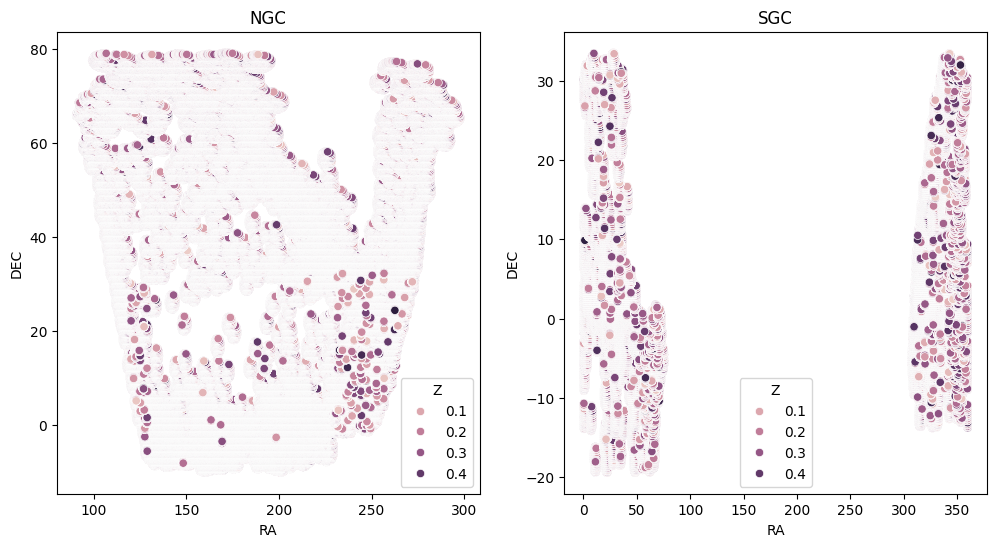

In [3]:
names = ["RA","DEC","Z"]
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
sns.scatterplot(NGC[names].to_pandas(), x="RA", y="DEC", hue="Z", ax=ax[0])
ax[0].set_title('NGC')
sns.scatterplot(SGC[names].to_pandas(), x="RA", y="DEC", hue="Z", ax=ax[1])
ax[1].set_title('SGC');

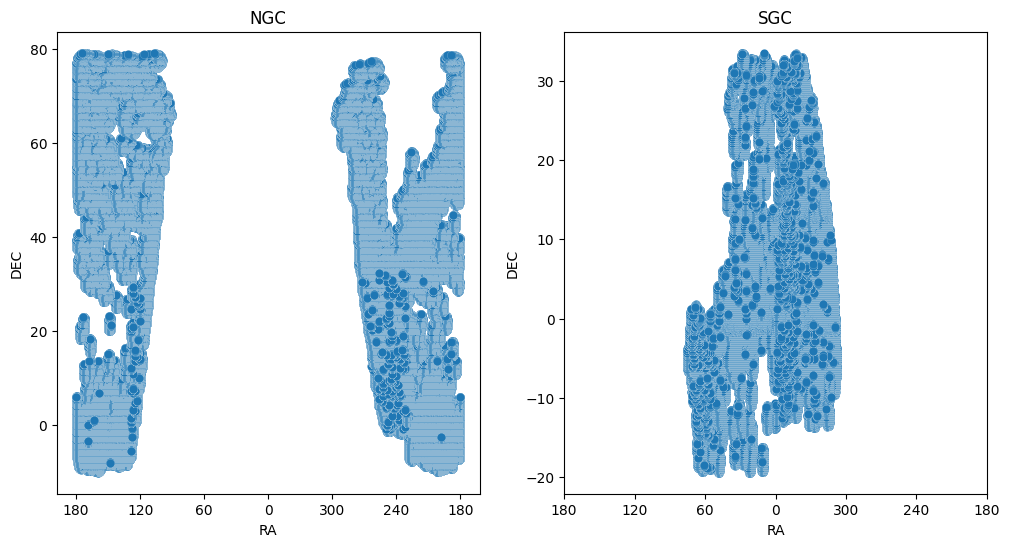

In [3]:
def recenter_RA(RA):
    return np.where(RA > 180,RA - 360, RA)

def plot_RADEC(RA, DEC, title='', RA_recenter=True, all_sky=True, **kwargs):
    if "figax" in kwargs.keys(): fig, ax = kwargs.pop("figax")
    else: fig, ax = plt.subplots()
    grid = kwargs.pop("grid", False)
    if RA_recenter: #make 360° correspond with 0°
        RA = RA.copy() #to not affect the data itself
        RA = recenter_RA(RA)
        RA_ticks = np.arange(-180, 201, 60)
        RA_labels = (RA_ticks + 360) % 360
    else:
        RA_ticks = np.arange(0, 361, 60)
        RA_labels = RA_ticks
    DEC_ticks = np.arange(-90, 91, 30)
    ax.scatter(RA, DEC, edgecolors='white', linewidths=0.1)
    if all_sky or RA_recenter:
        ax.set_xticks(RA_ticks)
        ax.set_xticklabels(RA_labels)
    if all_sky: ax.set_yticks(DEC_ticks)
    ax.invert_xaxis()
    ax.set_title(title)
    ax.set_xlabel("RA")
    ax.set_ylabel("DEC")
    if grid: ax.grid()

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
plot_RADEC(NGC["RA"], NGC["DEC"], title="NGC", figax = (fig, ax[0]), all_sky=False)
plot_RADEC(SGC["RA"], SGC["DEC"], title="SGC", figax = (fig, ax[1]), all_sky=False)

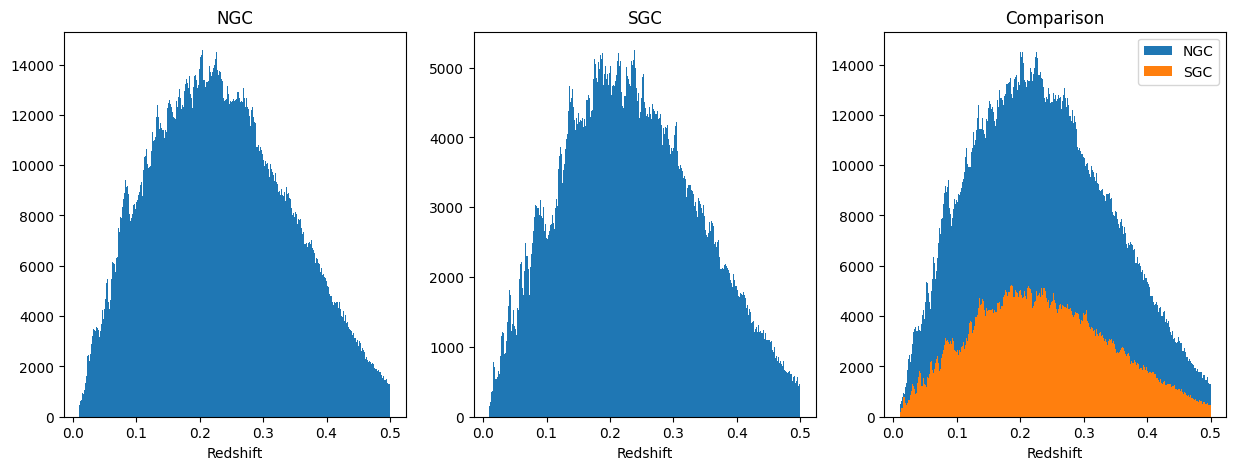

In [4]:
def histCompare_NS(col, xlabel, category=False, **kwargs):
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    xscale = kwargs.pop('xscale', "linear")
    if category: #qualitative variables
        sns.countplot(NGC[[col]].to_pandas(), x=col, ax=ax[0])
        ax[0].set_title("NGC")
        sns.countplot(SGC[[col]].to_pandas(), x=col, ax=ax[1])
        ax[1].set_title("SGC")
        sns.countplot(NGC[[col]].to_pandas(), x=col, ax=ax[2], label="NGC")
        sns.countplot(SGC[[col]].to_pandas(), x=col, ax=ax[2], label="SGC")
        ax[2].set_title("Comparison")
    else: #quantitative variables
        get_hist(NGC[col], xlabel=xlabel, title="NGC", show=False, figax = (fig, ax[0]), **kwargs)
        get_hist(SGC[col], xlabel=xlabel, title="SGC", show=False, figax = (fig, ax[1]), **kwargs)
        get_hist(NGC[col], xlabel=xlabel, title="Comparison", show=False, figax = (fig, ax[2]), label="NGC", **kwargs)
        get_hist(SGC[col], xlabel=xlabel, title="Comparison", show=False, figax = (fig, ax[2]), label="SGC", **kwargs)
        ax[2].legend()
        ax[0].set_xscale(xscale)
        ax[1].set_xscale(xscale)
        ax[2].set_xscale(xscale)
    return fig, ax

histCompare_NS("Z", "Redshift", bins=500);

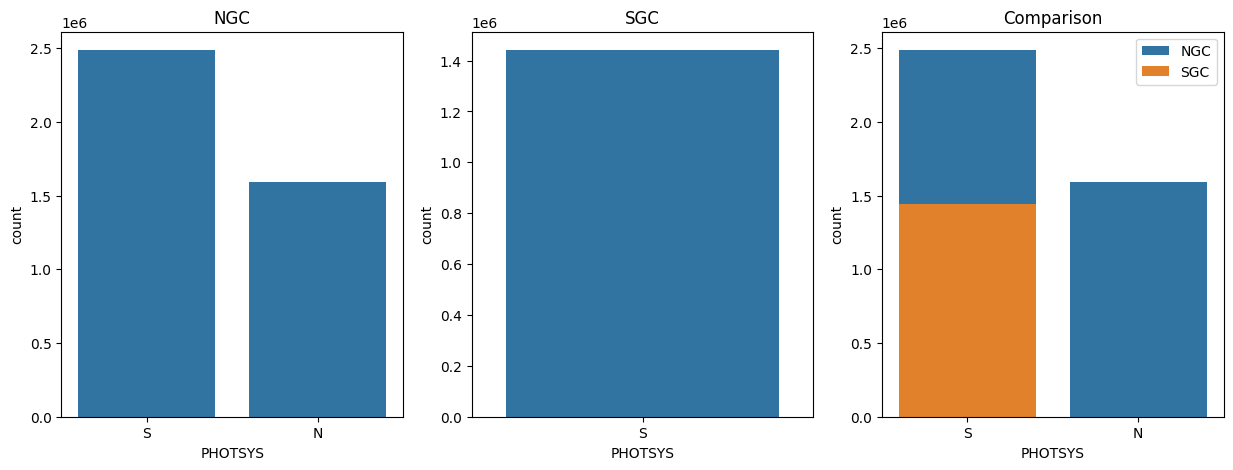

In [5]:
histCompare_NS("PHOTSYS", "PHOTSYS", category=True);

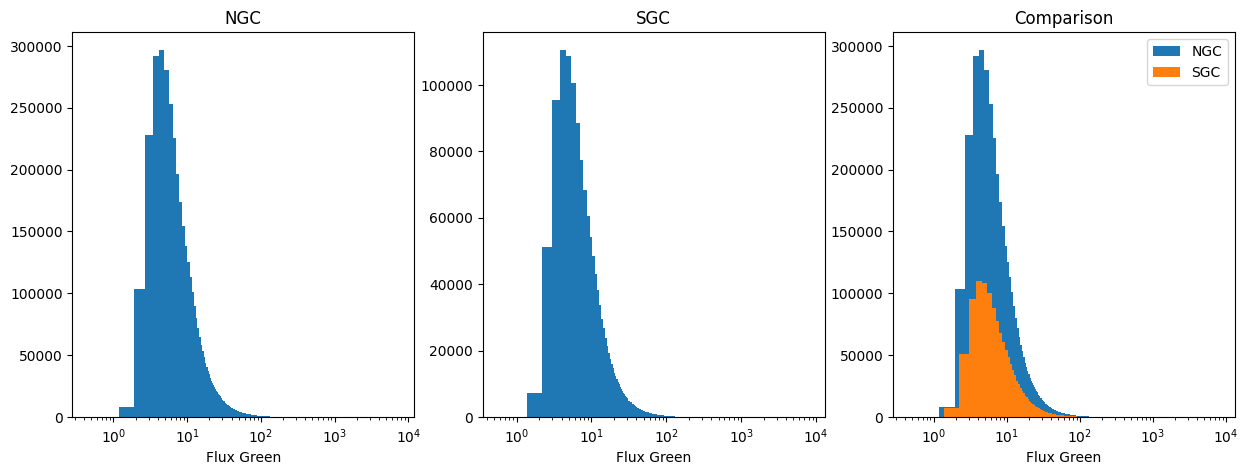

In [6]:
histCompare_NS("flux_g_dered", "Flux Green", bins=10000, xscale="log");

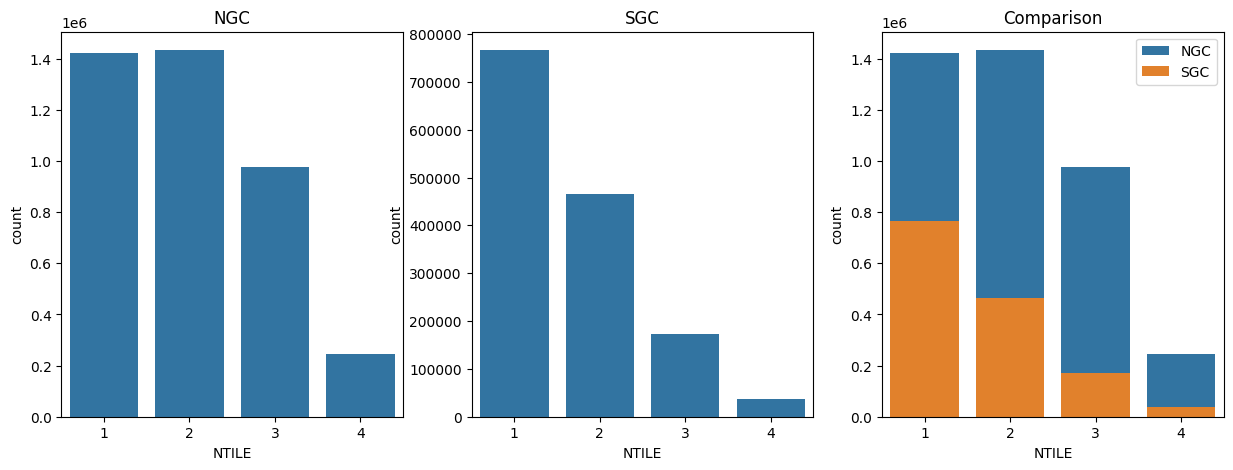

In [6]:
histCompare_NS("NTILE", "NTILE", category=True);

## Maps

In [3]:
NSIDE = 128
NPIX = hp.nside2npix(NSIDE)
area_deg2 = hp.nside2pixarea(NSIDE, degrees=True)
print("Number of pixels = {}".format(NPIX))
print("Surface of a pixel = {} deg^2".format(area_deg2))

Number of pixels = 196608
Surface of a pixel = 0.2098234113027917 deg^2


### NGC and SGC separated:

In [9]:
NSource_NGC = RADEC2NSource_Table(NSIDE, NGC, nest=True)
NSource_SGC = RADEC2NSource_Table(NSIDE, SGC, nest=True)
NSource_NGC_px, NSource_SGC_px = NSource_NGC/area_deg2, NSource_SGC/area_deg2

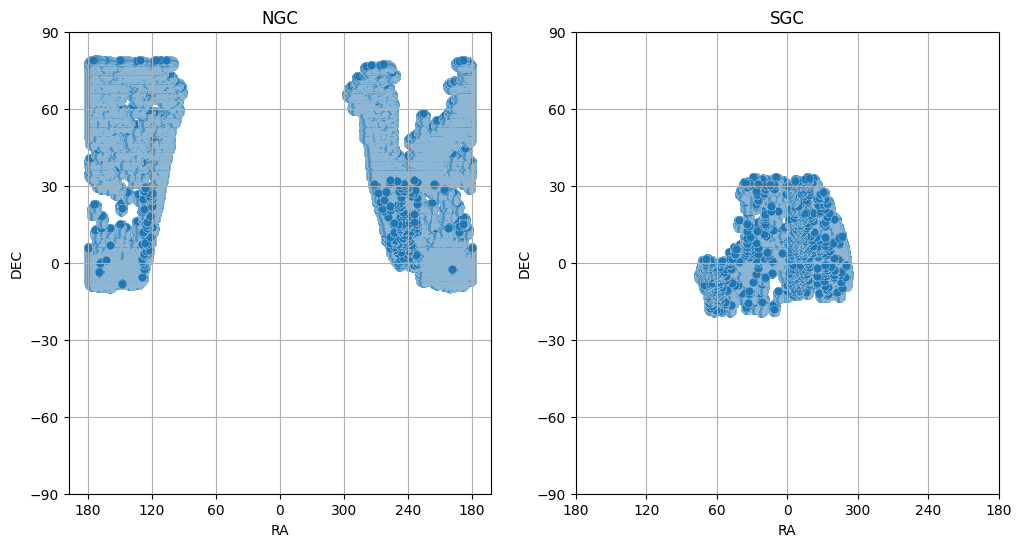

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
plot_RADEC(NGC["RA"], NGC["DEC"], title="NGC", figax = (fig, ax[0]), grid=True)
plot_RADEC(SGC["RA"], SGC["DEC"], title="SGC", figax = (fig, ax[1]), grid=True)

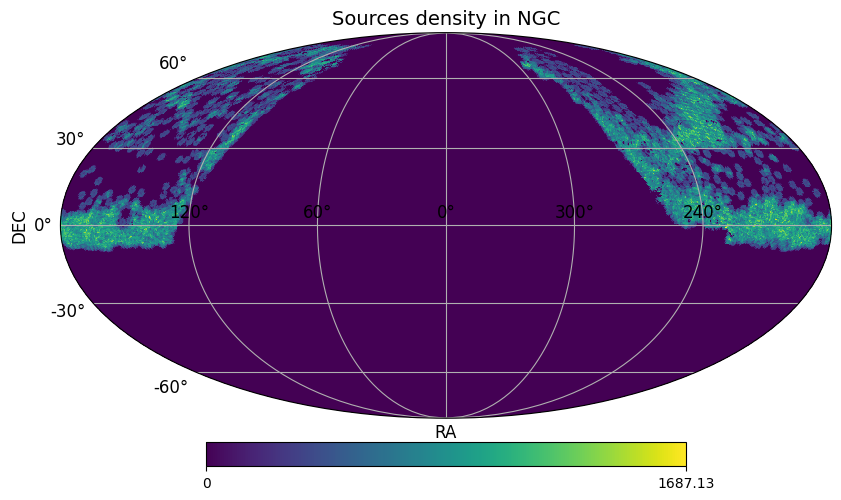

In [9]:
hp.projview(NSource_NGC_px, title="Sources density in NGC", nest=True, graticule=True, graticule_labels=True, projection_type="mollweide")
plt.xlabel("RA")
plt.ylabel("DEC");

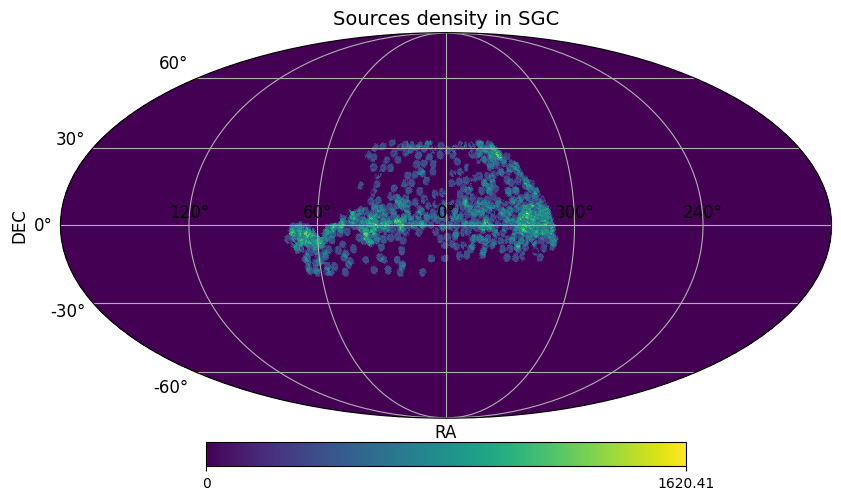

In [8]:
hp.projview(NSource_SGC_px, title="Sources density in SGC", nest=True, graticule=True, graticule_labels=True, projection_type="mollweide")
plt.xlabel("RA")
plt.ylabel("DEC");

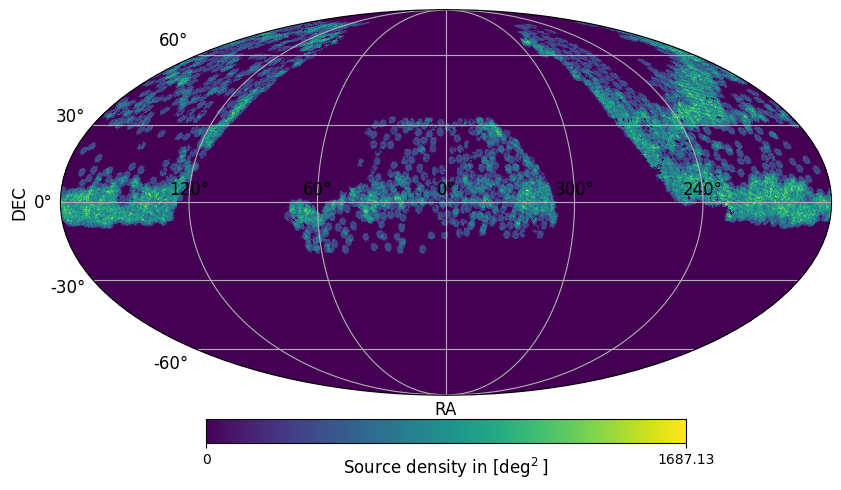

In [16]:
hp.projview(NSource_NGC_px+NSource_SGC_px, unit="Source density in $[\deg^2]$", nest=True, graticule=True, graticule_labels=True, projection_type="mollweide")
plt.xlabel("RA")
plt.ylabel("DEC")
plt.savefig(DIR + "DESI Figures/DESI_DR1_BGS_Source_Density_map.pdf", bbox_inches='tight');

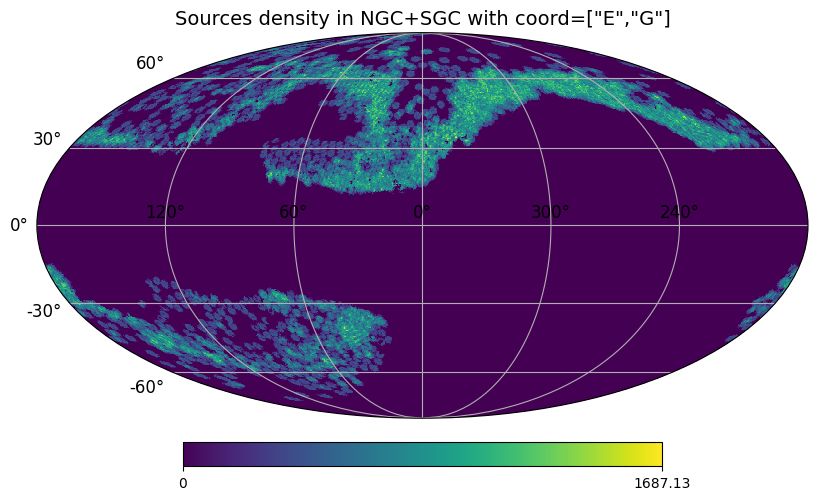

In [10]:
#to visualize better the galactic plane:
hp.projview(NSource_NGC_px+NSource_SGC_px, title='Sources density in NGC+SGC with coord=["E","G"]', nest=True, graticule=True, graticule_labels=True, projection_type="mollweide", coord=["E","G"]);

### Study of PHOTSYS from NGC:

Since NGC have both ```PHOTSYS = "S"``` and Since NGC have both ```PHOTSYS = "N"```, we decompose them here.

In [11]:
mask = NGC["PHOTSYS"] == "S"
NSource_NGC_S = RADEC2NSource_Table(NSIDE, NGC[mask], nest=True)
NSource_NGC_N = RADEC2NSource_Table(NSIDE, NGC[~mask], nest=True)
NSource_NGC_S_px, NSource_NGC_N_px = NSource_NGC_S/area_deg2, NSource_NGC_N/area_deg2

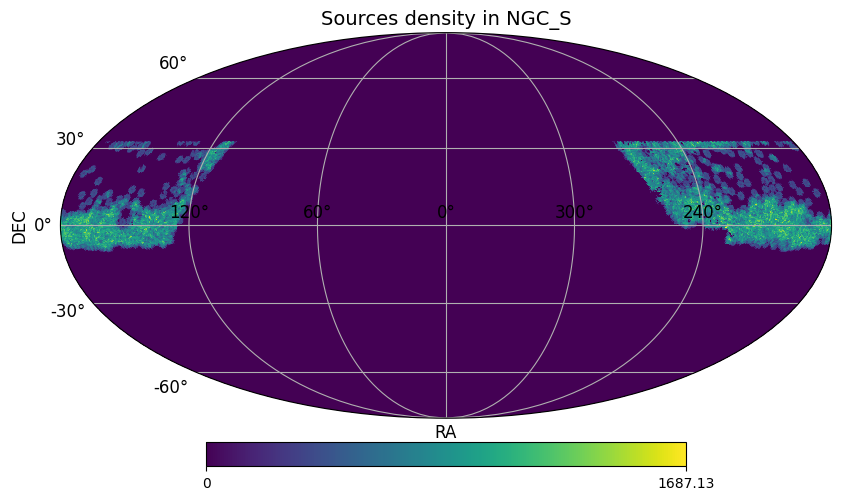

In [12]:
hp.projview(NSource_NGC_S_px, title="Sources density in NGC_S", nest=True, graticule=True, graticule_labels=True, projection_type="mollweide")
plt.xlabel("RA")
plt.ylabel("DEC");

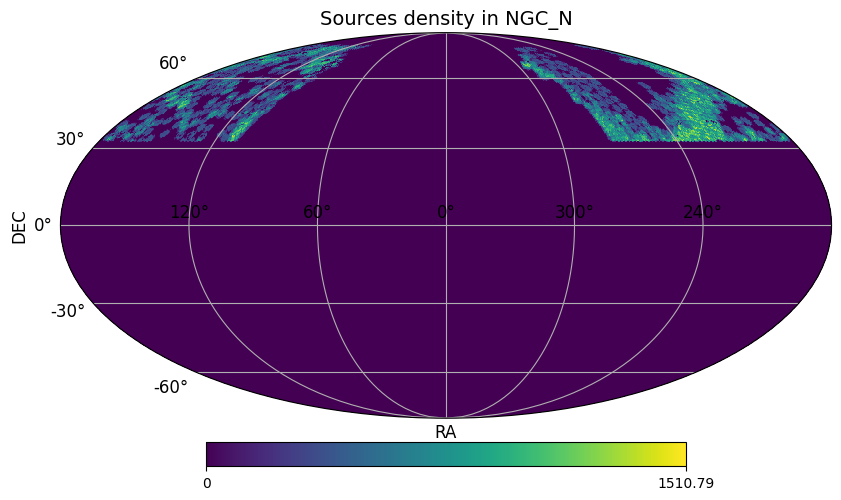

In [13]:
hp.projview(NSource_NGC_N_px, title="Sources density in NGC_N", nest=True, graticule=True, graticule_labels=True, projection_type="mollweide")
plt.xlabel("RA")
plt.ylabel("DEC");

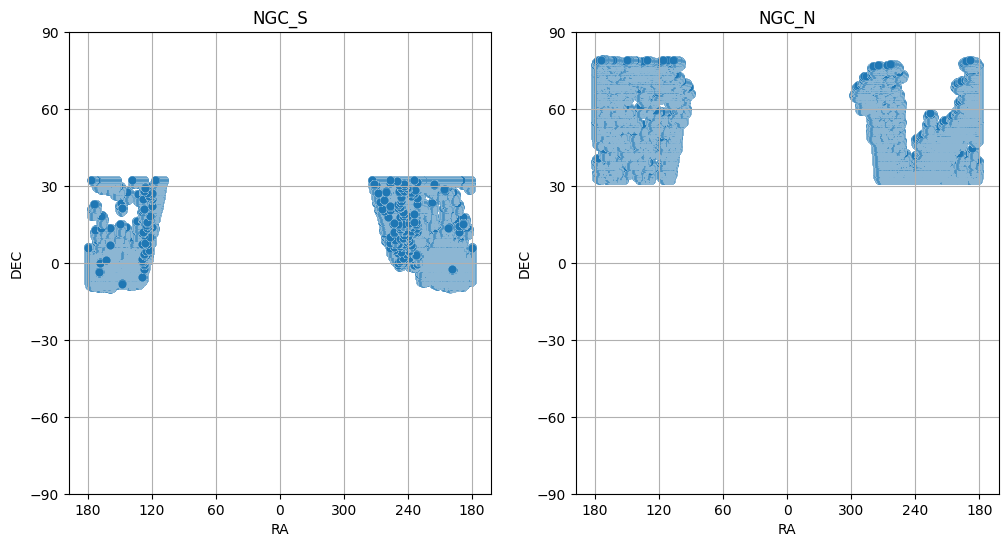

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
plot_RADEC(NGC["RA"][mask], NGC["DEC"][mask], title="NGC_S", figax = (fig, ax[0]), grid=True)
plot_RADEC(NGC["RA"][~mask], NGC["DEC"][~mask], title="NGC_N", figax = (fig, ax[1]), grid=True)

### Test with adaptation of Corentin function:

/tmp/ipykernel_9112/1890861682.py:52: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  color_map = cm.get_cmap(cmap)


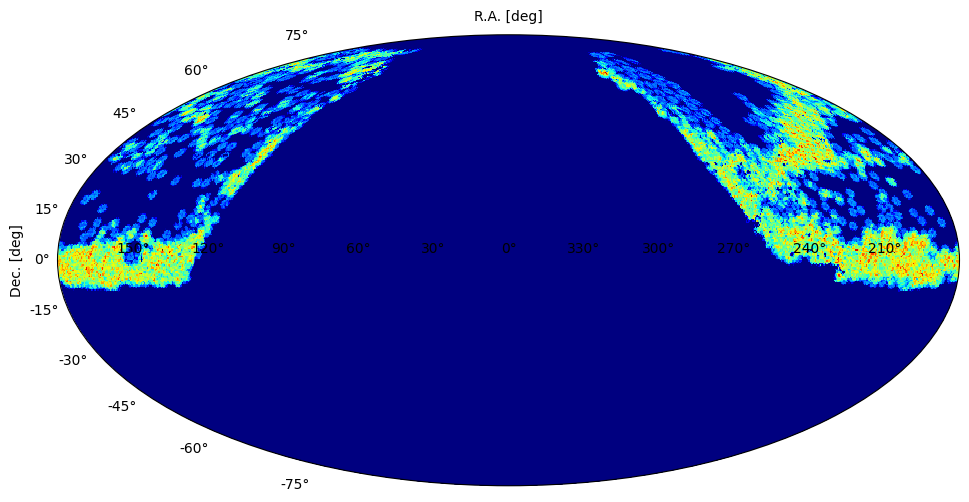

In [36]:
from matplotlib.lines import Line2D
from matplotlib import cm
import matplotlib.colors as mcolors

def plot_moll2(healpix_map,
              label,
              rot=120,
              cmap='jet',
              projection='mollweide', 
              figsize=(11.0, 7.0), 
              xpad=1.25, 
              labelpad=-37, 
              xlabel_labelpad=10.0, 
              ycb_pos=-0.15,
              show_legend=True):
    healpix_map = healpix_map.copy()
    # transform healpix map to 2d array
    plt.figure(1)
    m = hp.ma(healpix_map)
    map_to_plot = hp.cartview(m, nest=True, rot=rot, flip='geo', fig=1, return_projected_map=True)
    plt.close()

    # build ra, dec meshgrid to plot 2d array
    ra_edge = np.linspace(-180, 180, map_to_plot.shape[1] + 1)
    dec_edge = np.linspace(-90, 90, map_to_plot.shape[0] + 1)

    ra_edge[ra_edge > 180] -= 360    # scale conversion to [-180, 180]
    ra_edge = -ra_edge               # reverse the scale: East to the left

    ra_grid, dec_grid = np.meshgrid(ra_edge, dec_edge)

    plt.figure(figsize=figsize)
    ax = plt.subplot(111, projection=projection)
    plt.subplots_adjust(left=0.14, bottom=0.18, right=0.96, top=0.90)

    mesh = plt.pcolormesh(np.radians(ra_grid), np.radians(dec_grid), map_to_plot, cmap=cmap, edgecolor='none', lw=0)

    #ra, dec = hp.pix2ang(NSIDE, healpix_map, nest=True, lonlat=True)
    #ax.plot(np.radians(ra), np.radians(dec), linestyle='-', linewidth=0.8, color='black')


    tick_labels = np.array([150, 120, 90, 60, 30, 0, 330, 300, 270, 240, 210])
    tick_labels = np.remainder(tick_labels + 360 + rot, 360)
    tick_labels = np.array([f'{lab}°' for lab in tick_labels])
    ax.set_xticklabels(tick_labels)

    ax.set_xlabel('R.A. [deg]', labelpad=xlabel_labelpad)
    ax.xaxis.set_label_position('top')
    ax.set_ylabel('Dec. [deg]')

    healpix_map[healpix_map == 0.0] = np.nan
    color_map = cm.get_cmap(cmap)
    values_map = np.unique(healpix_map)[~np.isnan(np.unique(healpix_map))]

    if show_legend:
        legend_elements = [
            Line2D([],[],
                color= color_map((values_map[i] - np.min(values_map)) / (np.max(values_map) - np.min(values_map))),
                label= label[i],
                linestyle="-",
            )
            for i in range(len(values_map))
        ]  
        ax.legend(handles=legend_elements)
    
    return ax

plot_moll2(NSource_NGC_px, "NGC", rot=0, show_legend=False);

/tmp/ipykernel_26550/3812531920.py:51: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  color_map = cm.get_cmap(cmap)


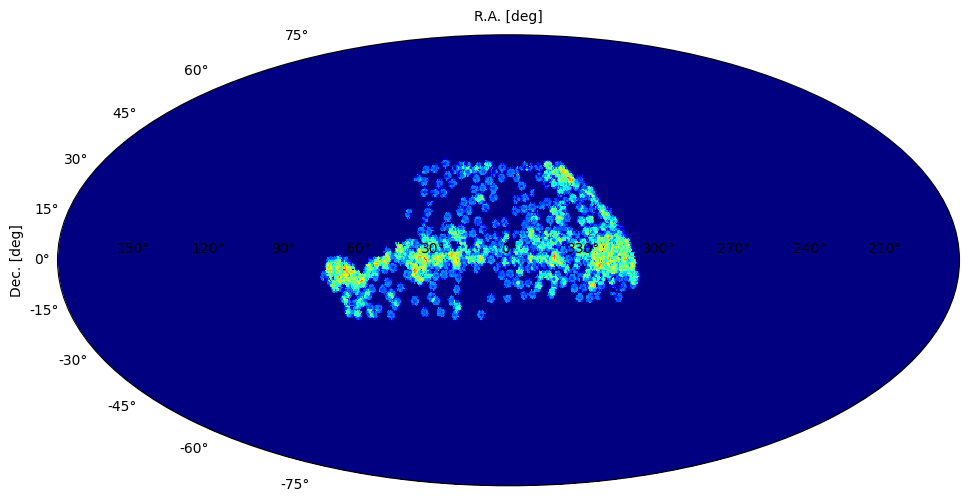

In [16]:
plot_moll2(NSource_SGC_px, "SGC", rot=0, show_legend=False);

/tmp/ipykernel_42244/1890861682.py:52: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  color_map = cm.get_cmap(cmap)


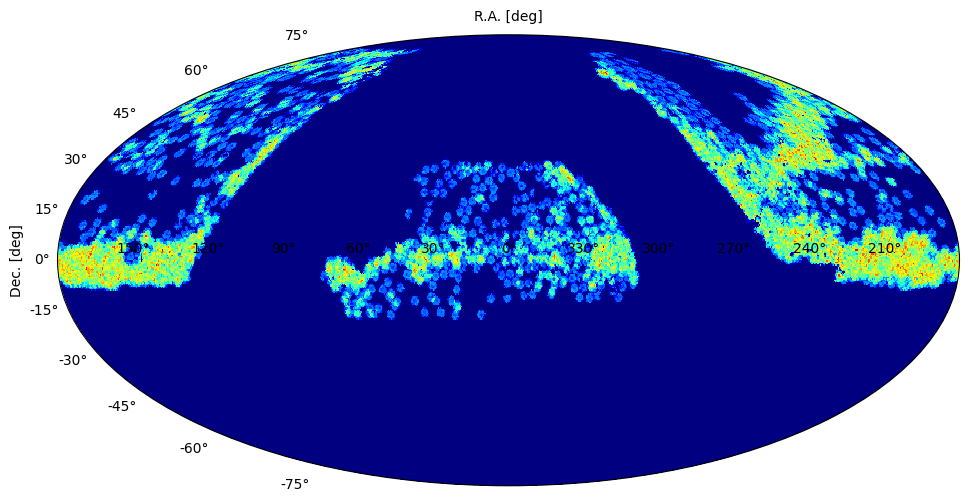

In [20]:
plot_moll2(NSource_NGC_px+NSource_SGC_px, ["NGC", "SGC"], rot=0, show_legend=False);

In [12]:
mask_NGC = NSource_NGC_px !=0
NSource_NGC_color = NSource_NGC_px.copy()
NSource_NGC_color[mask_NGC] = 4

mask_SGC = NSource_SGC_px !=0
NSource_SGC_color = NSource_SGC_px.copy()
NSource_SGC_color[mask_SGC] = 10

NSource_color = NSource_NGC_color + NSource_SGC_color
#NSource_color[NSource_color == 0.0] = np.nan

In [ ]:
plot_moll2(NSource_color, ["NGC", "SGC"], rot=0, show_legend=True);

/tmp/ipykernel_722/452267123.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  color_map = cm.get_cmap("jet")


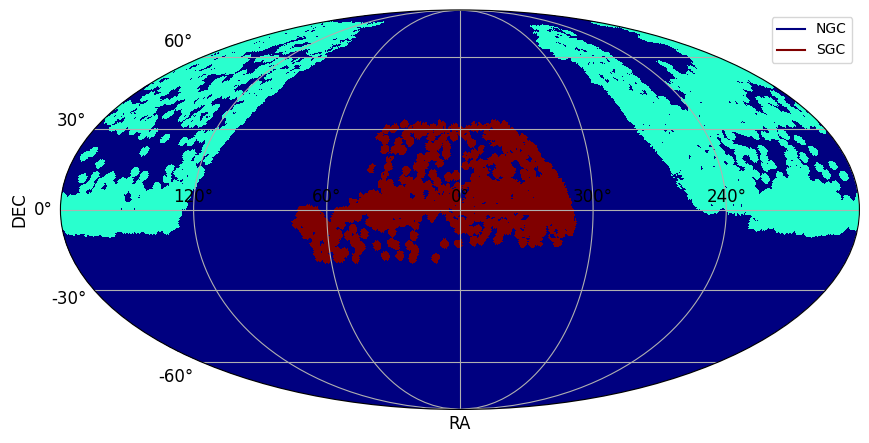

In [13]:
from matplotlib.lines import Line2D
from matplotlib import cm
import matplotlib.colors as mcolors

label = ["NGC", "SGC"]
color_map = cm.get_cmap("jet")
values_map = [4, 10]
legend_elements = [
        Line2D([],[],
            color= color_map((values_map[i] - np.min(values_map)) / (np.max(values_map) - np.min(values_map))),
            label= label[i],
            linestyle="-",
        )
        for i in range(len(values_map))
    ]  
    


hp.projview(NSource_color, unit="Sky region", nest=True, graticule=True, graticule_labels=True, projection_type="mollweide", cmap='jet', cbar=False)
plt.legend(handles=legend_elements)
plt.xlabel("RA")
plt.ylabel("DEC")
plt.savefig(DIR + "DESI Figures/DESI_DR1_BGS_Sky_Region_map.pdf", bbox_inches='tight');

### Other analysis:

In [25]:
#addinf pixel number by source:
px_colname = "px_Nside{}".format(NSIDE)
NGC.add_column(hp.ang2pix(NSIDE, NGC['RA'], NGC['DEC'], lonlat=True, nest=True), name=px_colname)
NGC[px_colname].unit = None
SGC.add_column(hp.ang2pix(NSIDE, SGC['RA'], SGC['DEC'], lonlat=True, nest=True), name=px_colname)
SGC[px_colname].unit = None
NGC

TARGETID,Z,NTILE,RA,DEC,PHOTSYS,FRAC_TLOBS_TILES,WEIGHT_ZFAIL,BITWEIGHTS,PROB_OBS,WEIGHT,WEIGHT_COMP,WEIGHT_SYS,flux_g_dered,flux_r_dered,flux_z_dered,flux_w1_dered,flux_w2_dered,NX,WEIGHT_FKP,px_Nside128
,,,deg,deg,,,,,,,,,nanomaggy,nanomaggy,nanomaggy,nanomaggy,nanomaggy,,,
int64,float64,int64,float64,float64,bytes1,float64,float64,int64[2],float64,float64,float64,float64,float32,float32,float32,float32,float32,float64,float64,int64
39627540901396542,0.11780978798091779,1,159.21336539688306,-10.1570784990642,S,0.986125385405961,1.0,-1 .. -1,1.0,0.4020310943321785,1.0,1.0,49.759033,82.394775,123.07306,107.12112,72.68243,0.013277792318345803,0.010644577467738883,106913
39627540901396881,0.18852438367491672,1,159.31752567050466,-10.126518405884719,S,0.986125385405961,1.0003317594528198,-1 .. -1,1.0,0.40216447194805066,1.0,1.0,4.465552,9.0119915,15.1033325,19.139269,17.25489,0.007570508503506765,0.01852072744982418,106913
39627546827951381,0.13939738520826428,1,157.87076725654435,-9.875451258938376,S,0.98491921005386,1.0000087022781372,-1 .. -1,1.0,0.4020345929185812,1.0,1.0,21.879585,30.944036,39.23734,31.118029,17.95399,0.011543794958537013,0.012223957863869393,106922
39627546832142517,0.13384342727980247,1,157.95311366416092,-9.89176181427952,S,0.98491921005386,1.0,-6502010112314306597 .. -7014319551088676288,0.34375,1.1524891370855783,2.8666666666666667,1.0,64.23985,161.47015,326.29388,286.1153,183.32571,0.011543794958537013,0.012223957863869393,106920
39627546832142599,0.13481237197080895,1,157.95938723949703,-9.900573678838345,S,0.98491921005386,1.0000147819519043,-1158348146330124321 .. -90865853993600030,0.6875,0.5827278403438851,1.449438202247191,1.0,13.473231,20.69669,29.218834,22.669884,17.1243,0.011543794958537013,0.012223957863869393,106920
39627546832144102,0.3277038731563745,1,158.0586254092098,-9.883478054340443,S,0.98491921005386,1.0,-1 .. -1,1.0,0.4020310943321785,1.0,1.0,4.8808885,13.26394,26.47439,35.094788,26.350426,0.0020923038580991644,0.0639135806306668,106920
39627546832144556,0.2804423196541022,1,158.0919034157211,-9.885985138196315,S,0.98491921005386,1.0000360012054443,-1 .. -1,1.0,0.40204556793620055,1.0,1.0,4.8884478,10.819805,16.304056,14.631474,10.874418,0.0033096766342485067,0.041377478709825624,106920
39627546832144612,0.1756295118675194,1,158.09744754077613,-9.948586941938014,S,0.98491921005386,1.0000108480453491,-8354376908713272321 .. -8487356173256100561,0.5390625,0.7408939110042868,1.8428571428571427,1.0,19.048483,29.186644,40.23485,27.274828,21.075787,0.008095592993999081,0.0173402934391804,106920


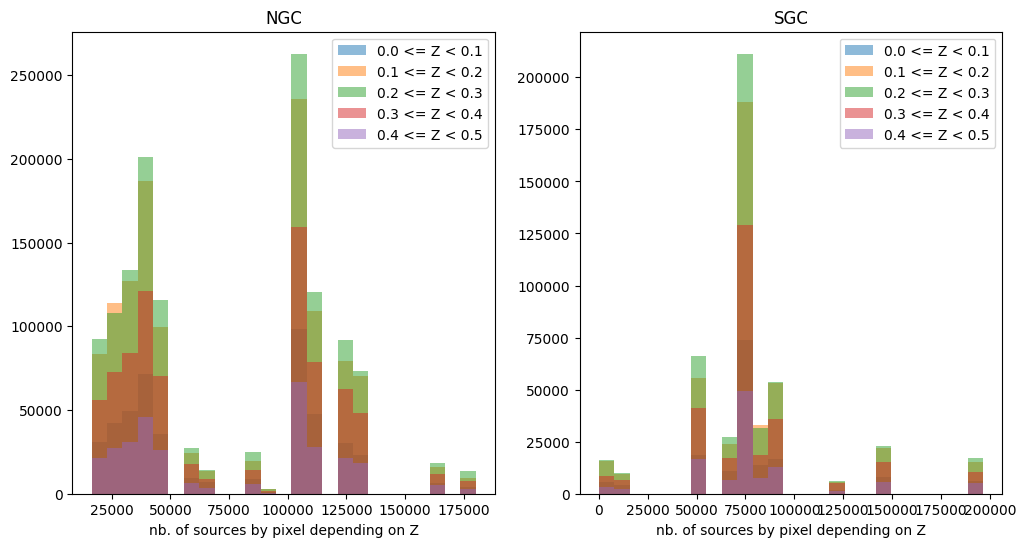

In [26]:
npins = 5
Z_lim = (np.arange(0, npins, 1).reshape([-1,1]))/10
masks_NGC = (NGC["Z"] >= Z_lim) & (NGC["Z"] < Z_lim+0.1)
masks_SGC = (SGC["Z"] >= Z_lim) & (SGC["Z"] < Z_lim+0.1)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
xlabel = "nb. of sources by pixel depending on Z"
bins = 25
for i in range(npins):
    label = "{} <= Z < {}".format(np.round(Z_lim[i, 0], 1), np.round(Z_lim[i, 0]+0.1, 1))
    ax[0].hist(NGC[px_colname][masks_NGC[i]], label=label, bins=bins, alpha=0.5)
    ax[0].set_title("NGC")
    ax[0].set_xlabel(xlabel)
    ax[0].legend()
    ax[1].hist(SGC[px_colname][masks_SGC[i]], label=label, bins=bins, alpha=0.5)
    ax[1].set_title("SGC")
    ax[1].set_xlabel(xlabel)
    ax[1].legend()

## Full DESI data

In [20]:
import fitsio
from astropy.table import Table
DIR = "Data DESI/"
FILE_full = DIR + "BGS_ANY_full.dat.fits"

In [ ]:
FullSky = fitsio.read(FILE_full, columns=["TARGET_STATE", "RA", "DEC"])
FullSky = Table(FullSky)
FullSky

In [ ]:
NSource_full_px = RADEC2NSource_Table(NSIDE, FullSky, nest=True)/area_deg2
hp.projview(NSource_full_px, title="Sources density in full sky", nest=True, graticule=True, graticule_labels=True, projection_type="mollweide")
plt.xlabel("RA")
plt.ylabel("DEC");

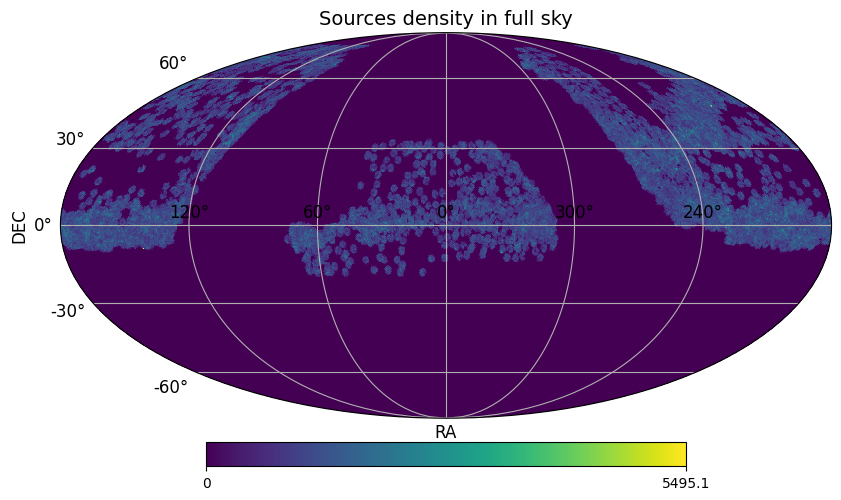

In [8]:
FullSky2 = fitsio.FITS(FILE_full)
ra, dec = FullSky2[1]["RA"][:],  FullSky2[1]["DEC"][:]
NSource_full_px2 = RADEC2NSource(NSIDE, ra, dec, nest=True)/area_deg2
hp.projview(NSource_full_px2, title="Sources density in full sky", nest=True, graticule=True, graticule_labels=True, projection_type="mollweide")
plt.xlabel("RA")
plt.ylabel("DEC");

## DESI code

In [1]:
from desisurveyops.status_sky import get_fns, plot_skymap

tilesfn = DIR + "tiles-BRIGHT.ecsv"
survey, specprod = "main", "iron"
program, npassmax, program_str = "BRIGHT", None, "BRIGHT"
case, quant = "obs", "fraccov"

# output files
outpng = "dr1-{}-{}.png".format(survey, program_str.lower())
outfits = outpng.replace(".png", ".fits")

# pick the last night for the program
t = Table.read(get_fns(survey=survey, specprod=specprod)["spec"]["tiles"])
night = t["LASTNIGHT"][t["FAFLAVOR"] == "{}{}".format(survey, program.lower())].max()

# run
plot_skymap(outpng, survey, specprod, program, npassmax, program_str, case, quant, night, tilesfn=tilesfn, outfits=outfits)

FileNotFoundError: [Errno 2] No such file or directory: '/home/victoria/Travaux_Jupyter_Ububtu/M2Stage/desi_packages/desimodel/py/desimodel/data/focalplane/fiberpos.fits'

## DR1

In [4]:
FILE_DR1 = DIR + "dr1-main-bright.fits"
DR1 = Table.read(FILE_DR1)
DR1

HPXPIXEL,RA,DEC,TILEIDS,EXPFACS,NPASS,EXPFAC_MEAN,NTILE,FRACCOV
int64,float64,float64,int64[4],float64[4],int64,float64,float64,float64
0,45.0,0.03730194242227469,0 .. 0,0.0 .. 0.0,1,1.9786394866210657,1.0,0.25
1,45.04394531249999,0.07460390065516265,0 .. 0,0.0 .. 0.0,1,1.9786394866210657,1.0,0.25
2,44.9560546875,0.07460390065516265,0 .. 0,0.0 .. 0.0,1,1.9786394866210657,1.0,0.25
3,45.0,0.11190589050941924,0 .. 0,0.0 .. 0.0,1,1.9786394866210657,1.0,0.25
4,45.08789062499999,0.11190589050941924,0 .. 0,0.0 .. 0.0,1,1.9786394866210657,1.0,0.25
5,45.13183593749999,0.14920792779581404,0 .. 0,0.0 .. 0.0,1,1.9786394866210657,1.0,0.25
6,45.04394531249999,0.14920792779581404,0 .. 0,0.0 .. 0.0,1,1.9786394866210657,1.0,0.25
7,45.08789062499999,0.18651002832535823,0 .. 0,0.0 .. 0.0,1,1.9786394866210657,1.0,0.25
8,44.912109375,0.11190589050941924,0 .. 0,0.0 .. 0.0,1,1.9786394866210657,1.0,0.25


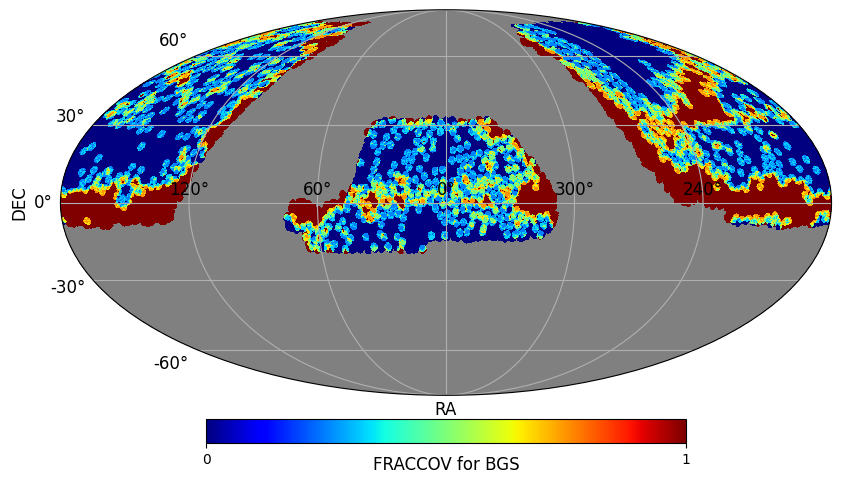

In [15]:
hp.projview(DR1['FRACCOV'], unit="FRACCOV for BGS", nest=True, graticule=True, graticule_labels=True, projection_type="mollweide", cmap='jet')
plt.xlabel("RA")
plt.ylabel("DEC")
plt.savefig(DIR + "DESI Figures/DESI_DR1_completness_map.pdf", bbox_inches='tight');

### First exploration

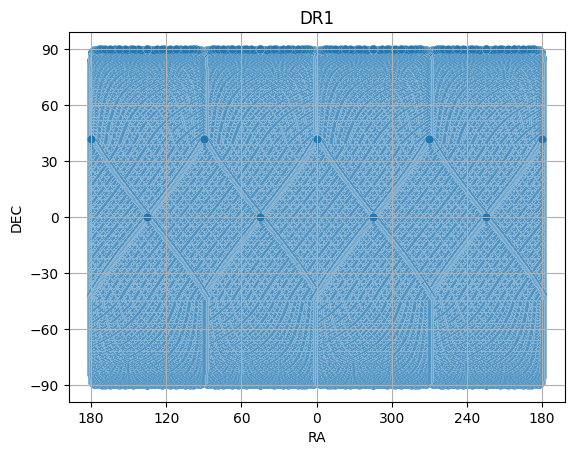

In [8]:
plot_RADEC(DR1["RA"], DR1["DEC"], title="DR1", grid=True);

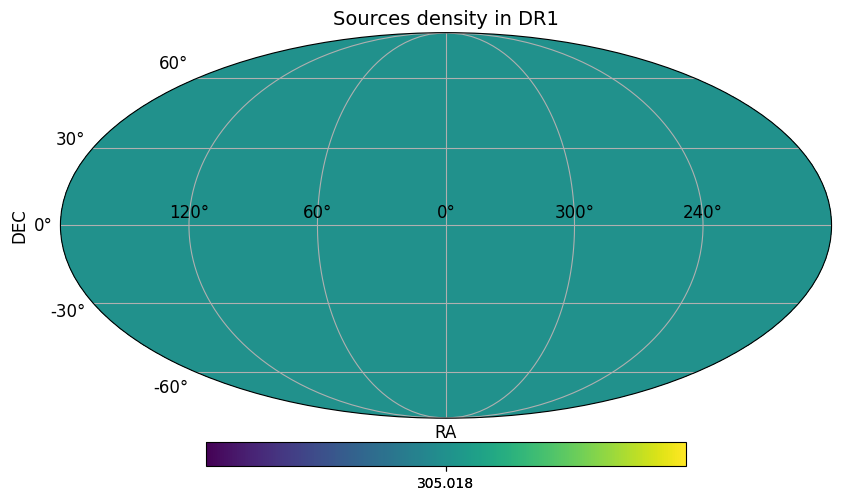

In [9]:
NSource_DR1_px = RADEC2NSource_Table(NSIDE, DR1, nest=True)/area_deg2
hp.projview(NSource_DR1_px, title="Sources density in DR1", nest=True, graticule=True, graticule_labels=True, projection_type="mollweide")
plt.xlabel("RA")
plt.ylabel("DEC");

<Axes: xlabel='RA', ylabel='DEC'>

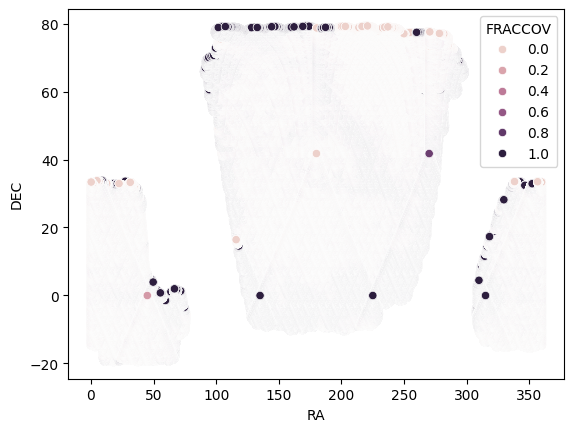

In [17]:
names = ["RA", "DEC", "FRACCOV"]
sns.scatterplot(DR1[names].to_pandas(), x="RA", y="DEC", hue="FRACCOV")

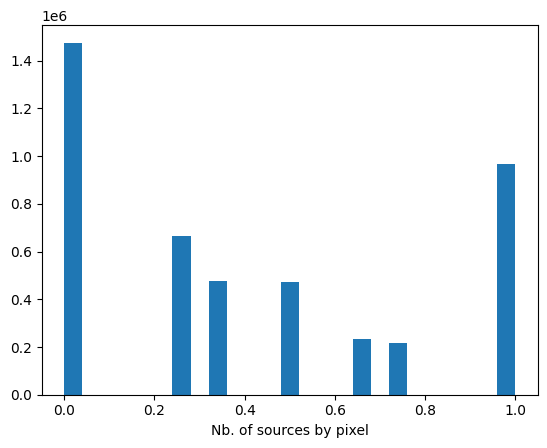

In [14]:
get_hist(DR1["FRACCOV"], bins=25);

In [15]:
np.unique(DR1["FRACCOV"])

0.0
0.2
0.25
0.3333333333333333
0.4
0.5
0.6
0.6666666666666666
0.75
0.8
1.0


### Completude map

In [17]:
maps, maps_color = [], []
cov_bins = np.linspace(0, 1, 5)
for cov_min, cov_max in zip(cov_bins[:-1], cov_bins[1:]):
    in_bin = (DR1["FRACCOV"] > cov_min) & (DR1["FRACCOV"] <= cov_max) #mask to select the desired data
    data = DR1[in_bin]
    map = RADEC2NSource_Table(NSIDE, data, nest=True)/area_deg2
    mask0 = map !=0 #to filter not empty pixels
    map_color = map.copy()
    map_color[mask0] = cov_max
    maps.append(map)
    maps_color.append(map_color)

maps, maps_color = np.array(maps), np.array(maps_color)
maps_color_normed = maps_color.sum(axis=0)
maps_color_normed /= maps_color_normed.max()
#maps_color_normed[maps_color_normed == 0] = np.nan
#maps_color_normed

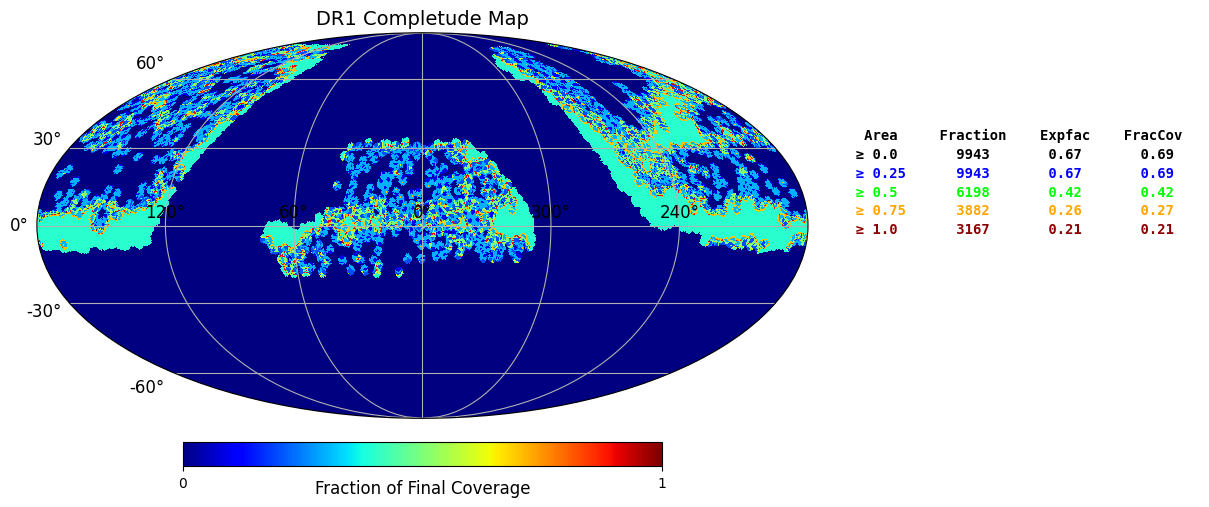

In [18]:
# Text data
data = {"Area": [9943, 9943, 6198, 3882, 3167],
    "Fraction": [0.67, 0.67, 0.42, 0.26, 0.21],
    "Expfac": [0.69, 0.69, 0.42, 0.27, 0.21]}
data["FracCov"] = [f'≥ {cov_bins[i]}' for i in range(len(cov_bins))]
data["colors"] = ["black", "blue", "lime", "orange", "darkred"]
data = pd.DataFrame(data)
headers = data.columns.difference(['colors'], sort=False)

format_line = " ".join(["{:^" + str(10) + "}"] * len(headers)) #{:^nb} : align on the center on nb characters

hp.projview(maps_color_normed, title="DR1 Completude Map", nest=True, graticule=True, graticule_labels=True, projection_type="mollweide", cmap='jet', unit="Fraction of Final Coverage")

# Test position:
x_start = 1  # horizontal position  (0 to 1)
y_start = 0.75  # vertical position
line_space = 0.035 # pace between lignes

# Text titles:
header_str = format_line.format(*headers) #farmating the text as a table
plt.text(x_start, y_start, header_str, fontsize=10, weight='bold', #weight='bold' : met en gras ; family='monospace' : police où chaque caratère occupe la même place
         family='monospace', transform=plt.gcf().transFigure) #transform=plt.gcf().transFigure : indique x, y comme fraction de la figure, indépendemment des coord des axes

# Text line with colors
for i, row in enumerate(data.itertuples()):
    
    row_str = format_line.format(row.FracCov, row.Area, row.Fraction, row.Expfac)
    
    plt.text(x_start, y_start - (i + 1) * line_space, row_str, 
             color=row.colors, fontsize=10, weight='semibold',
             family='monospace', transform=plt.gcf().transFigure);